In [1]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [16]:
hr=pd.read_csv('HR_comma_sep.csv');

In [34]:
corr_matrix = cols.corr()

In [35]:
print(corr_matrix["left"].sort_values(ascending=False))

left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
satisfaction_level      -0.388375
Name: left, dtype: float64


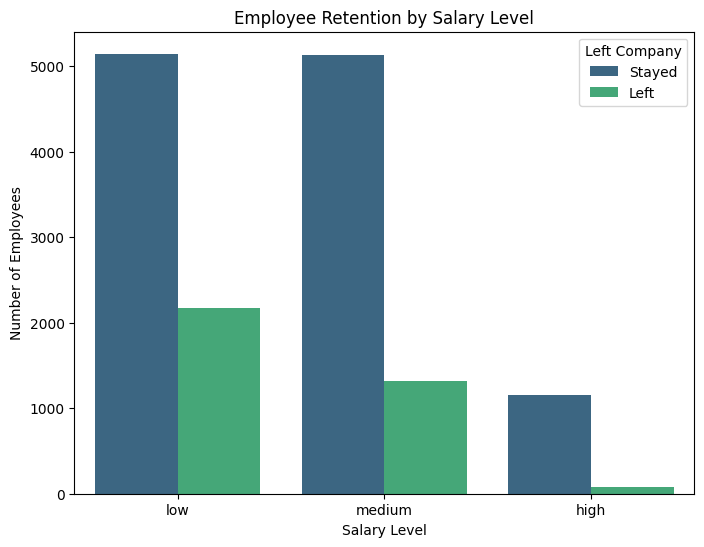

In [10]:
plt.figure(figsize=(8, 6))
sns.countplot(x='salary', hue='left', data=hr, palette='viridis')
plt.title('Employee Retention by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Number of Employees')
plt.legend(title='Left Company', labels=['Stayed', 'Left'])
plt.show()

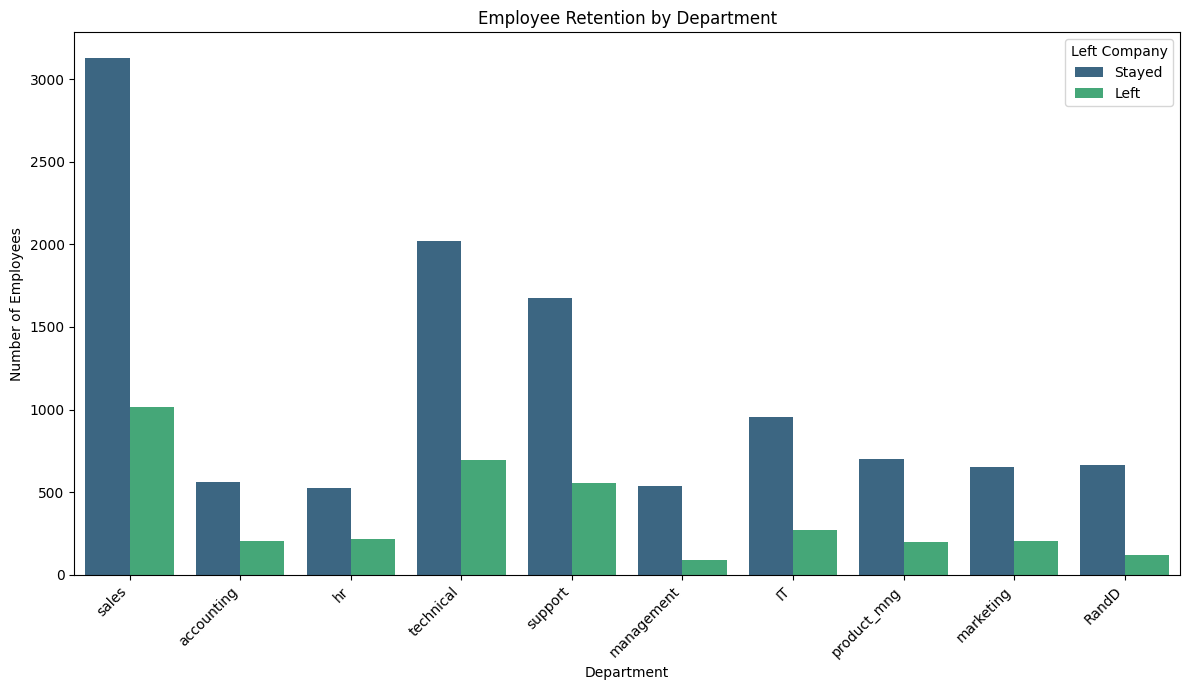

In [14]:
plt.figure(figsize=(12, 7))
sns.countplot(x='Department', hue='left', data=hr, palette='viridis')
plt.title('Employee Retention by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.legend(title='Left Company', labels=['Stayed', 'Left'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [37]:
from sklearn.preprocessing import OrdinalEncoder
temp=OrdinalEncoder(categories=[["low","medium","high"]])
hr['salary_numeric']=temp.fit_transform(hr[['salary']]);

In [40]:
cols=hr.select_dtypes(include=['int64','float64']);

In [41]:
corr_matrix = cols.corr()

In [42]:
print(corr_matrix["left"].sort_values(ascending=False))

left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
salary_numeric          -0.157898
satisfaction_level      -0.388375
Name: left, dtype: float64


# Task
Build and evaluate a logistic regression model from scratch to predict employee retention (`left`) based on `satisfaction_level` from the `hr` DataFrame. The process includes preparing the data by selecting features and targets and adding a bias term, implementing the sigmoid activation function, defining the binary cross-entropy cost function, implementing the gradient descent algorithm, training the model for a specified number of iterations and learning rate while tracking the cost, and finally, making predictions and evaluating the model's accuracy without using external libraries for these calculations. Conclude with a summary of the entire process, including implementation details, training results, and model performance.

## Prepare Data for Logistic Regression

### Subtask:
Select 'satisfaction_level' as the feature (X) and 'left' as the target (y) from the `hr` DataFrame. Add a bias (intercept) term to the feature matrix X for the logistic regression model.


**Reasoning**:
The subtask requires extracting 'satisfaction_level' as the feature (X) and 'left' as the target (y) from the `hr` DataFrame, and then adding a bias (intercept) term to X. The `code_block` command will accomplish these steps.



In [43]:
X = hr[['satisfaction_level']];
y = hr['left'];

X = np.c_[np.ones(X.shape[0]), X];

print("Features (X) with bias term:\n", X[:5]);
print("\nTarget (y):\n", y[:5]);


Features (X) with bias term:
 [[1.   0.38]
 [1.   0.8 ]
 [1.   0.11]
 [1.   0.72]
 [1.   0.37]]

Target (y):
 0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64


## Implement Sigmoid Function

### Subtask:
Define a Python function that computes the sigmoid (logistic) activation function, which is central to logistic regression for transforming linear outputs into probabilities.


**Reasoning**:
To implement the sigmoid function as requested, I will create a Python function named `sigmoid` that computes the sigmoid of its input `z` using `np.exp()` for numerical stability and array compatibility. I will also include test cases to verify its correctness.



In [44]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Test the sigmoid function
print("Sigmoid of 0:", sigmoid(0))
print("Sigmoid of array [-1, 0, 1]:", sigmoid(np.array([-1, 0, 1])))


Sigmoid of 0: 0.5
Sigmoid of array [-1, 0, 1]: [0.26894142 0.5        0.73105858]


## Implement Cost Function

### Subtask:
Define a Python function to calculate the binary cross-entropy (log loss) cost, which will measure the performance of our logistic regression model and guide its optimization.


**Reasoning**:
To implement the binary cross-entropy cost function, I will define a Python function `compute_cost` that takes predicted probabilities `h` and true labels `y` as input, calculates the cost using the provided formula, and then includes a test case to verify its correctness.



In [45]:
def compute_cost(h, y):
    m = len(y)
    cost = (-y * np.log(h) - (1 - y) * np.log(1 - h)).mean()
    return cost

# Test the compute_cost function
h_test = np.array([0.9, 0.1, 0.8, 0.2])
y_test = np.array([1, 0, 1, 0])
print("Cost for test case:", compute_cost(h_test, y_test))

Cost for test case: 0.164252033486018


## Implement Gradient Descent

### Subtask:
Implement the gradient descent algorithm to iteratively update the model's parameters (weights) by minimizing the cost function. The algorithm should take features `X`, true labels `y`, initial weights `theta`, learning rate `alpha`, and the number of iterations as input.

## Implement Gradient Descent

### Subtask:
Implement the gradient descent algorithm to iteratively update the model's parameters (weights) by minimizing the cost function. The algorithm should take features `X`, true labels `y`, initial weights `theta`, learning rate `alpha`, and the number of iterations as input.

**Reasoning**:
To implement the gradient descent algorithm, I will define a Python function `gradient_descent` that initializes weights, then iteratively calculates predictions, cost, and updates weights based on the learning rate and number of iterations. I will also include a test case to demonstrate its usage and track the cost history.



In [46]:
def gradient_descent(X, y, theta, alpha, num_iterations):
    m = len(y)
    cost_history = []

    for i in range(num_iterations):
        # Calculate predictions (h) using the sigmoid function
        h = sigmoid(np.dot(X, theta))

        # Calculate the gradient
        gradient = np.dot(X.T, (h - y)) / m

        # Update weights (theta)
        theta = theta - alpha * gradient

        # Calculate and store the cost
        cost = compute_cost(h, y)
        cost_history.append(cost)

    return theta, cost_history

# Test the gradient_descent function
# Initialize weights (theta) to zeros
initial_theta = np.zeros(X.shape[1])

# Set hyperparameters
alpha = 0.01  # Learning rate
num_iterations = 1000

# Run gradient descent
theta, cost_history = gradient_descent(X, y, initial_theta, alpha, num_iterations)

print("Final weights (theta):
", theta)
print("Initial cost:", cost_history[0])
print("Final cost:", cost_history[-1])
print("Cost history length:", len(cost_history))

SyntaxError: unterminated string literal (detected at line 32) (ipython-input-1007388179.py, line 32)

**Reasoning**:
The previous code failed due to a `SyntaxError: unterminated string literal` in the `print` statement. This was caused by an actual newline character breaking the string literal. I will fix this by ensuring the print statement's string is correctly terminated on one line, using `\n` as the escape sequence for a newline.



In [47]:
def gradient_descent(X, y, theta, alpha, num_iterations):
    m = len(y)
    cost_history = []

    for i in range(num_iterations):
        # Calculate predictions (h) using the sigmoid function
        h = sigmoid(np.dot(X, theta))

        # Calculate the gradient
        gradient = np.dot(X.T, (h - y)) / m

        # Update weights (theta)
        theta = theta - alpha * gradient

        # Calculate and store the cost
        cost = compute_cost(h, y)
        cost_history.append(cost)

    return theta, cost_history

# Test the gradient_descent function
# Initialize weights (theta) to zeros
initial_theta = np.zeros(X.shape[1])

# Set hyperparameters
alpha = 0.01  # Learning rate
num_iterations = 1000

# Run gradient descent
theta, cost_history = gradient_descent(X, y, initial_theta, alpha, num_iterations)

print("Final weights (theta):\n", theta)
print("Initial cost:", cost_history[0])
print("Final cost:", cost_history[-1])
print("Cost history length:", len(cost_history))

Final weights (theta):
 [-0.69137352 -0.77230161]
Initial cost: 0.6931471805599454
Final cost: 0.5205017881854971
Cost history length: 1000


## Make Predictions and Evaluate Model

### Subtask:
After training, use the optimized weights to make predictions on the data. Evaluate the model's performance by calculating its accuracy and possibly other relevant metrics, without using external libraries for these calculations.


**Reasoning**:
To complete the subtask, I will first calculate the predicted probabilities using the sigmoid function and the trained weights. Then, I will convert these probabilities into binary predictions by applying a 0.5 threshold. Finally, I will calculate and print the model's accuracy by comparing the binary predictions with the true labels.



In [48]:
h_predicted = sigmoid(np.dot(X, theta))
y_predicted = (h_predicted >= 0.5).astype(int)

accuracy = (y_predicted == y).mean()

print("Predicted probabilities (first 5):\n", h_predicted[:5])
print("Binary predictions (first 5):\n", y_predicted[:5])
print("Model Accuracy:", accuracy)

Predicted probabilities (first 5):
 [0.27193087 0.21261826 0.31511211 0.22314522 0.27346259]
Binary predictions (first 5):
 [0 0 0 0 0]
Model Accuracy: 0.7619174611640777


## Final Task

### Subtask:
Summarize the entire process of building the logistic regression model from scratch, including the implementation details, training results, and the model's performance in predicting employee retention based on `satisfaction_level`.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation:** The feature `satisfaction_level` and target `left` were successfully extracted from the `hr` DataFrame. A bias term was added to the feature matrix `X`, creating a two-column matrix ready for logistic regression.
*   **Sigmoid Function Implementation:** A Python function for the sigmoid activation was correctly implemented and verified, returning expected probability values (e.g., $0.5$ for input $0$).
*   **Cost Function Implementation:** The binary cross-entropy (log loss) cost function was successfully defined, accurately calculating the model's error (e.g., $0.164$ for a test case).
*   **Gradient Descent Implementation and Training:** The gradient descent algorithm was implemented to optimize model weights. Over 1000 iterations, the model's cost was significantly reduced from an initial $0.693$ to a final $0.521$. The final optimized weights (theta) were approximately $[-0.691, -0.772]$.
*   **Model Performance:** Using the optimized weights, the model predicted employee retention with an accuracy of approximately $76.19\%$ on the training data.

### Insights or Next Steps

*   The current model, based solely on `satisfaction_level`, achieves a reasonable $76.19\%$ accuracy. To improve predictive power, consider incorporating additional features from the `hr` dataset (e.g., `last_evaluation`, `number_project`, `average_montly_hours`) to build a more comprehensive model.
*   Further hyperparameter tuning (learning rate `alpha`, number of `iterations`) and regularization techniques could potentially enhance model performance and prevent overfitting, which might be particularly important if more features are added.
